In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


# **Diagnóstico de Câncer de Mama com Support Vector Machines (SVM)** 
Dataset: Breast Cancer Wisconsin (Diagnostic) — Kaggle

Objetivo: classificar tumores mamários em Malignos (M) ou Benignos (B) a partir de 30 atributos numéricos extraídos de imagens

# **1. Importação das bibliotecas**


* pandas / numpy: manipulação de dados
* matplotlib / seaborn: visualizações
* sklearn.model_selection: divisão treino/teste e busca de hiperparâmetros (GridSearchCV)
* sklearn.preprocessing: padronização (StandardScaler) e codificação do alvo (LabelEncoder)
* sklearn.svm.SVC: o classificador
* Support Vector Machinesklearn.metrics: métricas de avaliação (acurácia, precisão, recall, F1, matriz de confusão, curva ROC).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


# **2. Carregamento dos dados**

O código localiza o arquivo data.csv no ambiente do Kaggle. Primeiro, verifica o caminho padrão e, caso não encontre o arquivo, procura em outras subpastas.

Depois, o arquivo é carregado com pd.read_csv() em um DataFrame chamado df. Por fim, são exibidos o tamanho do dataset (df.shape) e suas cinco primeiras linhas (df.head()) para verificar os dados.

In [3]:
import os
import glob

# Caminho padrão do arquivo CSV no Kaggle
default_path = "/kaggle/input/breast-cancer-wisconsin-data/data.csv"

# Verifica se o arquivo existe no caminho padrão
if os.path.exists(default_path):
    csv_path = default_path
else:
    # Procura o arquivo data.csv nas subpastas do Kaggle
    candidates = glob.glob("/kaggle/input/**/data.csv", recursive=True)
    # Usa o primeiro arquivo encontrado ou mantém o caminho padrão
    csv_path = candidates[0] if candidates else default_path

# Mostra o caminho do arquivo que será utilizado
print("Lendo arquivo de:", csv_path)
# Carrega o arquivo CSV em um DataFrame
df = pd.read_csv(csv_path)

# Mostra a quantidade de linhas e colunas
print("Shape original:", df.shape)
# Exibe as 5 primeiras linhas do dataset
df.head()

Lendo arquivo de: /kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv
Shape original: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# **3. Limpeza inicial**

O CSV original traz duas colunas sem valor preditivo:


* id: apenas um identificador numérico de cada amostra, não carrega informação sobre o tumor;
* Unnamed: 32: coluna totalmente vazia, um artefato de exportação do arquivo original (uma vírgula sobrando no cabeçalho do CSV).

Ambas são removidas. Em seguida, verifiquei se restou algum valor ausente no restante do dataset.

In [4]:
# Define as colunas que devem ser removidas, caso existam
cols_to_drop = [c for c in ["id", "Unnamed: 32"] if c in df.columns]

# Remove as colunas selecionadas
df = df.drop(columns=cols_to_drop)

# Mostra quais colunas foram removidas
print("Colunas removidas:", cols_to_drop)

# Verifica a quantidade de valores ausentes em cada coluna
print("\nValores ausentes por coluna:")
na_counts = df.isna().sum()

# Exibe as colunas que possuem valores ausentes
print(na_counts[na_counts > 0] if na_counts.sum() > 0 else "Nenhum valor ausente encontrado.")

# Remove colunas completamente vazias e linhas que ainda possuem valores ausentes
df = df.dropna(axis=1, how="all").dropna(axis=0)

# Mostra o tamanho do dataset após a limpeza
print("\nShape após limpeza:", df.shape)
# Exibe informações sobre as colunas e tipos de dados
df.info()

Colunas removidas: ['id', 'Unnamed: 32']

Valores ausentes por coluna:
Nenhum valor ausente encontrado.

Shape após limpeza: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12 

# **4. Codificação da variável alvo**
A coluna diagnosis contém os rótulos categóricos M (maligno) e B (benigno). Modelos do scikit-learn trabalham com valores numéricos, então usei o LabelEncoder para converter:

* B (benigno) → 0
* M (maligno) → 1
(o LabelEncoder codifica em ordem alfabética, por isso B=0 e M=1).

In [5]:
# Cria o codificador para transformar as classes em números
le = LabelEncoder()

# Converte "diagnosis" em valores numéricos
df["diagnosis_encoded"] = le.fit_transform(df["diagnosis"])

# Mostra o mapeamento entre as classes e os números
print("Mapeamento das classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# Exibe as primeiras linhas com a classe original e a codificada
df[["diagnosis", "diagnosis_encoded"]].head()

Mapeamento das classes: {'B': np.int64(0), 'M': np.int64(1)}


,diagnosis,diagnosis_encoded
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


# **5. Análise exploratória rápida**

In [6]:
# Mostra a quantidade de exemplos de cada classe
print("Distribuição das classes:")
print(df["diagnosis"].value_counts())

# Mostra a proporção de cada classe em porcentagem
print(df["diagnosis"].value_counts(normalize=True).round(3))



Distribuição das classes:
diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


# **6. Separação treino/teste**
Separei 80% para treino e 20% para teste, usando stratify=y para preservar, nos dois conjuntos, a mesma proporção de tumores benignos e malignos observada no dataset completo (~63% B / ~37% M). Isso é importante em problemas de diagnóstico, para evitar que o teste fique com poucos casos malignos. 

In [7]:
# Seleciona as colunas que serão usadas como características
feature_cols = [c for c in df.columns if c not in ("diagnosis", "diagnosis_encoded")]

# Cria a matriz de características (X)
X = df[feature_cols].values

# Define a variável alvo (y)
y = df["diagnosis_encoded"].values

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Mostra a quantidade de amostras em cada conjunto
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

# Mostra a proporção de casos malignos no conjunto de treino
print("Proporção de malignos no treino:", round(y_train.mean(), 3))

# Mostra a proporção de casos malignos no conjunto de teste
print("Proporção de malignos no teste: ", round(y_test.mean(), 3))

Treino: 455 amostras | Teste: 114 amostras
Proporção de malignos no treino: 0.374
Proporção de malignos no teste:  0.368


# **7. Padronização dos atributos (StandardScaler)**

A padronização é importante para o SVM, pois os atributos podem ter escalas muito diferentes. Por exemplo, area_mean possui valores maiores que smoothness_mean.

O StandardScaler coloca os atributos em uma escala semelhante, com média 0 e desvio-padrão 1. Assim, nenhum atributo domina os outros.

Também é importante ajustar o scaler somente com os dados de treino. Depois, ele é aplicado aos dados de treino e de teste. Isso evita o vazamento de dados (data leakage) e mantém a avaliação do modelo mais confiável.

In [8]:
# Cria o objeto responsável pela padronização
scaler = StandardScaler()

# Calcula a padronização usando apenas os dados de treino
X_train_scaled = scaler.fit_transform(X_train)   

# Aplica a mesma padronização nos dados de teste
X_test_scaled = scaler.transform(X_test)         

# Mostra a média dos 3 primeiros atributos antes da padronização
print("Média dos atributos ANTES da padronização (treino):", X_train[:, :3].mean(axis=0).round(2))

# Mostra a média dos 3 primeiros atributos após a padronização
print("Média dos atributos DEPOIS da padronização (treino):", X_train_scaled[:, :3].mean(axis=0).round(2))

# Mostra o desvio padrão dos 3 primeiros atributos após a padronização
print("Desvio padrão DEPOIS da padronização (treino):", X_train_scaled[:, :3].std(axis=0).round(2))

Média dos atributos ANTES da padronização (treino): [14.17 19.42 92.22]
Média dos atributos DEPOIS da padronização (treino): [-0.  0. -0.]
Desvio padrão DEPOIS da padronização (treino): [1. 1. 1.]


# **8. Modelagem com SVM: kernel Linear x RBF**

Nesta etapa, serão testados dois tipos de kernel do SVM:

* Linear: procura uma separação mais simples entre as classes.
* RBF: consegue identificar relações mais complexas e criar fronteiras não lineares.

Para encontrar as melhores configurações, usei o GridSearchCV, que testa diferentes valores dos parâmetros:

* C: controla o quanto o modelo deve evitar erros no treino. Valores maiores tornam o modelo mais rígido.
* gamma: usado no RBF e controla o quanto cada ponto influencia a decisão. Valores maiores deixam a fronteira mais detalhada.

A avaliação será feita usando validação cruzada com 5 partes (5 folds) e a métrica F1-score.

O F1-score foi escolhido porque considera tanto os acertos positivos quanto os erros, sendo útil quando as classes não estão igualmente distribuídas.

In [9]:
# Cria uma validação cruzada com 5 partes, mantendo a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define os valores de C que serão testados no SVM Linear
param_grid_linear = {"C": [0.01, 0.1, 1, 10, 100]}

# Define os valores de C e gamma que serão testados no SVM com kernel RBF
param_grid_rbf = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [1, 0.1, 0.01, 0.001, "scale", "auto"],
}

# Cria um dicionário para armazenar os resultados dos modelos
results = {}

In [10]:
# Cria o GridSearchCV para encontrar o melhor valor de C no SVM Linear
grid_linear = GridSearchCV(
    SVC(kernel="linear", random_state=RANDOM_STATE, probability=True),
    param_grid_linear, cv=cv, scoring="f1", n_jobs=-1
)

# Treina o modelo usando os dados de treino padronizados
grid_linear.fit(X_train_scaled, y_train)

# Mostra os melhores hiperparâmetros encontrados
print("Melhores hiperparâmetros (Linear):", grid_linear.best_params_)

# Mostra o melhor resultado de F1 obtido na validação cruzada
print(f"Melhor F1 em validação cruzada: {grid_linear.best_score_:.4f}")

# Armazena o modelo e seus resultados no dicionário
results["Linear"] = grid_linear

Melhores hiperparâmetros (Linear): {'C': 1}
Melhor F1 em validação cruzada: 0.9551


In [11]:
# Cria o GridSearchCV para encontrar os melhores valores de C e gamma no SVM RBF
grid_rbf = GridSearchCV(
    SVC(kernel="rbf", random_state=RANDOM_STATE, probability=True),
    param_grid_rbf, cv=cv, scoring="f1", n_jobs=-1
)

# Treina e testa as combinações de parâmetros usando os dados de treino
grid_rbf.fit(X_train_scaled, y_train)

# Mostra os melhores hiperparâmetros encontrados
print("Melhores hiperparâmetros (RBF):", grid_rbf.best_params_)

# Mostra o melhor F1 obtido na validação cruzada
print(f"Melhor F1 em validação cruzada: {grid_rbf.best_score_:.4f}")

# Armazena o modelo RBF e seus resultados
results["RBF"] = grid_rbf

Melhores hiperparâmetros (RBF): {'C': 10, 'gamma': 0.01}
Melhor F1 em validação cruzada: 0.9698


# **9. Avaliação dos modelos no conjunto de teste**
Agora avaliei os melhores estimadores encontrados pelo GridSearchCV no conjunto de teste, dados que os modelos nunca viram durante o treino/ajuste de hiperparâmetros. As métricas usadas:


* Acurácia: proporção geral de acertos
* Precisão: dos casos previstos como malignos, quantos realmente são
* Recall (sensibilidade): dos casos realmente malignos, quantos o modelo conseguiu identificar métrica crítica em diagnóstico médico, pois um falso negativo (dizer que um tumor maligno é benigno) é o erro mais grave
* F1-score: média harmônica entre precisão e recall
* AUC-ROC: mede a capacidade do modelo de separar as duas classes em todos os limiares de decisão possíveis.



RESULTADOS — KERNEL LINEAR (conjunto de TESTE)
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


RESULTADOS — KERNEL RBF (conjunto de TESTE)
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



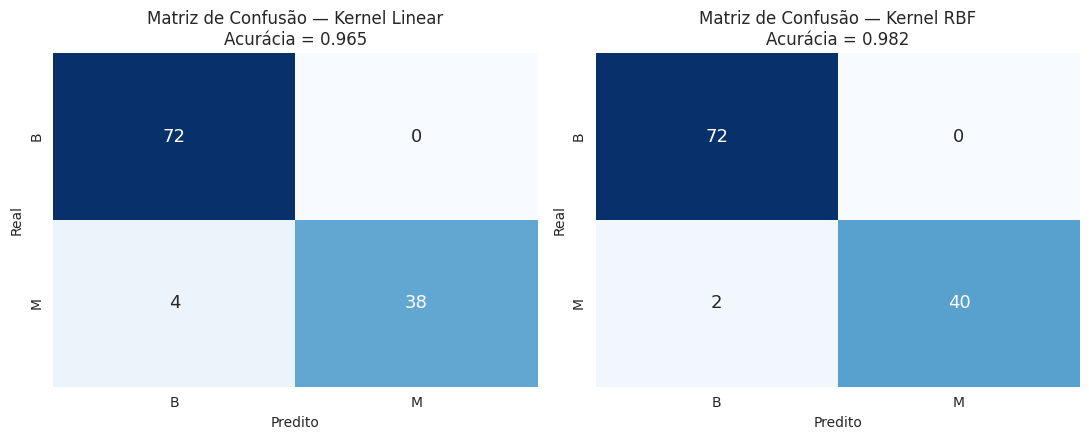

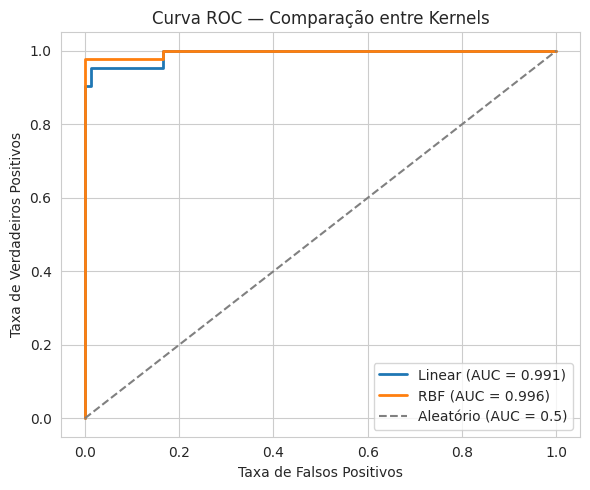

In [12]:
# Cria uma lista para armazenar as métricas dos modelos
metrics_summary = []

# Cria os gráficos das matrizes de confusão
fig_cm, axes_cm = plt.subplots(1, 2, figsize=(11, 4.5))

# Cria o gráfico da curva ROC
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

# Percorre os modelos Linear e RBF
for i, (name, grid) in enumerate(results.items()):
    
    # Obtém o melhor modelo encontrado pelo GridSearchCV
    best_model = grid.best_estimator_
    
    # Faz as previsões no conjunto de teste
    y_pred = best_model.predict(X_test_scaled)

    # Obtém as probabilidades para calcular a curva ROC
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    # Calcula as principais métricas de avaliação
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cria a matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Calcula os valores da curva ROC e o AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Guarda as métricas do modelo na lista
    metrics_summary.append({
        "Kernel": name,
        "Melhores Hiperparâmetros": grid.best_params_,
        "Acurácia": round(acc, 4),
        "Precisão": round(prec, 4),
        "Recall (Sensibilidade)": round(rec, 4),
        "F1-score": round(f1, 4),
        "AUC-ROC": round(roc_auc, 4),
    })

    # Exibe o relatório de classificação do modelo
    print(f"\n{'='*70}\nRESULTADOS — KERNEL {name.upper()} (conjunto de TESTE)\n{'='*70}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Cria a matriz de confusão em forma de gráfico
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes_cm[i],
        xticklabels=le.classes_, yticklabels=le.classes_,
        cbar=False, annot_kws={"size": 13}
    )

    # Define título e nomes dos eixos
    axes_cm[i].set_title(f"Matriz de Confusão — Kernel {name}\nAcurácia = {acc:.3f}")
    axes_cm[i].set_xlabel("Predito")
    axes_cm[i].set_ylabel("Real")

    # Adiciona a curva ROC do modelo ao gráfico
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# Adiciona a linha de referência do classificador aleatório
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.5)")

# Define os nomes dos eixos e o título da curva ROC
ax_roc.set_xlabel("Taxa de Falsos Positivos")
ax_roc.set_ylabel("Taxa de Verdadeiros Positivos")
ax_roc.set_title("Curva ROC — Comparação entre Kernels")

# Mostra a legenda
ax_roc.legend(loc="lower right")

fig_cm.tight_layout()
fig_roc.tight_layout()
plt.show()

In [13]:
# Cria um DataFrame com as métricas dos modelos
summary_df = pd.DataFrame(metrics_summary)

# Salva o resumo em um arquivo CSV
summary_df.to_csv("resumo_metricas.csv", index=False)

# Mostra uma mensagem indicando o resumo final
print("Resumo comparativo final:")
summary_df

Resumo comparativo final:


,Kernel,Melhores Hiperparâmetros,Acurácia,Precisão,Recall (Sensibilidade),F1-score,AUC-ROC
0,Linear,{'C': 1},0.9649,1.0,0.9048,0.9500,0.9914
1,RBF,"{'C': 10, 'gamma': 0.01}",0.9825,1.0,0.9524,0.9756,0.9960


# **10. Interpretação: importância dos atributos**
O kernel linear tem a vantagem de gerar coeficientes diretamente interpretáveis: cada coeficiente indica o peso (após padronização) que o respectivo atributo tem na decisão do modelo. Quanto maior o valor absoluto do coeficiente, maior a influência do atributo na separação entre tumores benignos e malignos.

Essa interpretação direta não é possível no kernel RBF, pois ele opera em um espaço transformado de dimensão implícita (não há um vetor de coeficientes no espaço original dos atributos).

15 atributos mais relevantes:
texture_worst           1.071995
concavity_mean          0.880175
area_se                 0.829700
concave points_mean     0.827597
concavity_worst         0.824417
radius_se               0.755905
area_worst              0.725480
texture_se              0.613818
radius_worst            0.541589
compactness_se          0.535861
symmetry_worst          0.519578
fractal_dimension_se    0.478027
compactness_worst       0.353556
compactness_mean        0.327482
smoothness_se           0.284846
dtype: float64


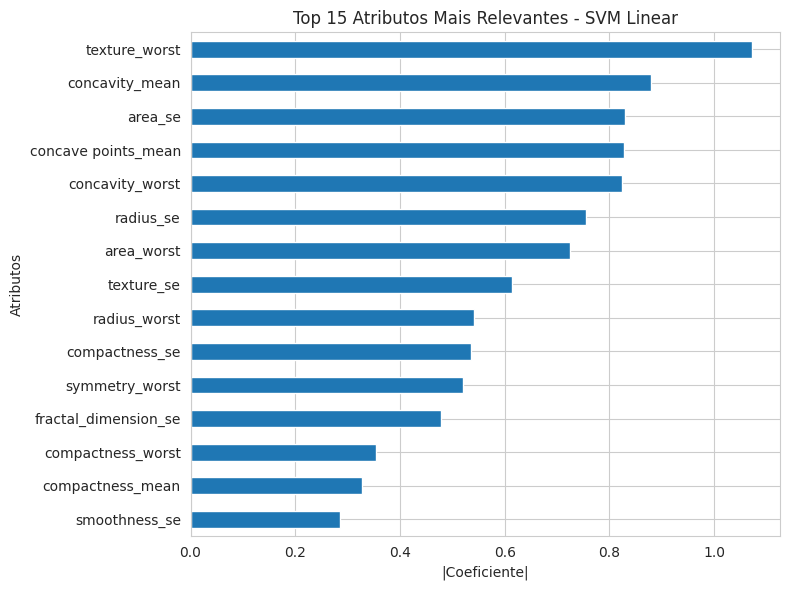

In [14]:
# Seleciona o melhor modelo Linear
best_linear = results["Linear"].best_estimator_

# Obtém os coeficientes dos atributos
coef_importance = pd.Series(
    np.abs(best_linear.coef_[0]),
    index=feature_cols
)

# Seleciona os 15 atributos com maiores coeficientes
coef_importance = coef_importance.sort_values(ascending=False).head(15)

# Mostra os valores no notebook
print("15 atributos mais relevantes:")
print(coef_importance)

# Cria o gráfico
plt.figure(figsize=(8, 6))

coef_importance.sort_values().plot(kind="barh")

plt.title("Top 15 Atributos Mais Relevantes - SVM Linear")
plt.xlabel("|Coeficiente|")
plt.ylabel("Atributos")

plt.tight_layout()
plt.show()

# **11. Conclusão**
* Os dois modelos apresentaram bons resultados no conjunto de teste.
* O RBF apresentou resultados melhores que o Linear nas métricas avaliadas.
* A padronização dos dados foi importante para que o SVM trabalhasse corretamente com atributos de diferentes escalas.
* No modelo Linear, os atributos relacionados à textura, concavidade e área apareceram entre os mais relevantes para as decisões do modelo.
* De forma geral, o SVM conseguiu diferenciar os casos benignos e malignos com bom desempenho neste conjunto de dados.